# Projeto Capstone de Análise de Dados do Google: Estudo de caso da Cyclistic

A Cyclistic é uma empresa fictícia de compartilhamento de bicicletas localizada em Chicago, que oferece opções de uso para clientes casuais e planos de assinatura para membros.

O objetivo deste projeto é entender as diferenças de uso entre eles para ajudar a aumentar o número de assinaturas do plano anual.

## Dados utilizados

Os dados utilizados são informações públicas disponibilizadas pela Divvy Bikes e mostram o histórico de viagens realizadas ao longo de 2025, usando dados como o tipo de cliente, os horários de início e fim das viagens, a duração e o dia da semana para responder à pergunta do estudo.

## Ferramentas

A análise foi feita no Jupyter Notebook com Python, utilizando Pandas para organizar e analisar os dados e Matplotlib para visualização dos dados.

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

files = sorted(glob.glob("data/*.csv"))

df = pd.concat([pd.read_csv(file) for file in files], ignore_index=True)

## Processamento

Os dados foram processados com a conversão das colunas de data para o formato correto, o cálculo da duração das viagens e a criação de colunas como dia da semana e hora de início de cada viagem.

In [2]:
df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds() / 60
df["day_of_week"] = df["started_at"].dt.dayofweek
df["hour"] = df["started_at"].dt.hour

## Análise

A análise compara o uso das bicicletas entre clientes casuais e membros, usando os dias da semana e a duração das viagens para entender as diferenças.

### Duração das viagens

A tabela abaixo mostra o tempo médio das viagens para cada tipo de cliente e ajuda a entender se as bicicletas são usadas mais para deslocamentos rápidos ou para passeios mais longos.

In [3]:
df.groupby("member_casual")["ride_length"].mean().round(1).reset_index()

,member_casual,ride_length
0,casual,22.6
1,member,12.3


### Viagens por dia da semana

O gráfico abaixo mostra o número de viagens em cada dia da semana e ajuda a entender se o uso é maior nos dias úteis ou nos finais de semana.

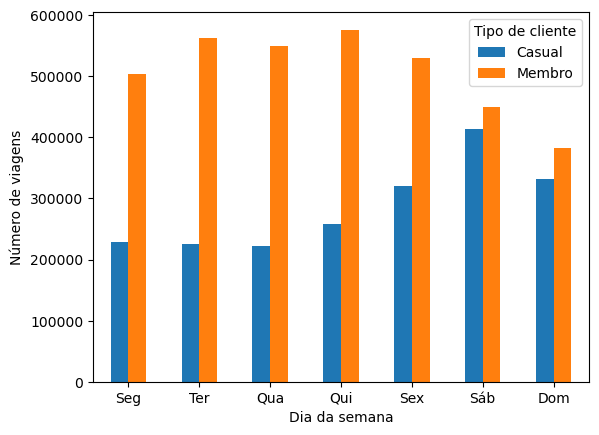

In [4]:
df.groupby(["day_of_week", "member_casual"]).size().unstack().plot(kind="bar")

plt.xlabel("Dia da semana")
plt.ylabel("Número de viagens")
plt.legend(["Casual", "Membro"], title="Tipo de cliente")

plt.xticks(range(7), ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"], rotation=0)

plt.savefig("grafico-uso-semanal-cyclistic.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusão

A análise mostrou que clientes casuais usam as bicicletas mais para lazer e fazem viagens mais longas, enquanto membros usam o serviço no dia a dia com viagens curtas e frequentes durante a semana.

## Recomendações

A empresa pode mostrar no aplicativo a diferença de preço entre viagens avulsas e o plano anual, apresentar o plano em alguns momentos após o fim da viagem e oferecer um período de teste gratuito.